In [1]:
import numpy as np
import struct
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

In [2]:
## Configuration and File Paths
train_labels_fpath = "mnist-dataset/train-labels-idx1-ubyte/train-labels-idx1-ubyte"
train_images_fpath = "mnist-dataset/train-images-idx3-ubyte/train-images-idx3-ubyte"
test_labels_fpath = "mnist-dataset/t10k-labels-idx1-ubyte/t10k-labels-idx1-ubyte"
test_images_fpath = "mnist-dataset/t10k-images-idx3-ubyte/t10k-images-idx3-ubyte"
np.random.seed(2023115) ## Setting Seed for Reproducibility

In [3]:
def load_dataset(image_file, label_file):
    with open(label_file, 'rb') as f:
        magic, num = struct.unpack(">II", f.read(8))
        labels = np.frombuffer(f.read(), dtype=np.uint8)
    with open(image_file, 'rb') as f:
        magic, num, rows, cols = struct.unpack(">IIII", f.read(16))
        images = np.frombuffer(f.read(), dtype=np.uint8).reshape(num, rows, cols)
    return images, labels
    

In [4]:
def preprocess(images):
    max_pixel_value = 255.0
    samples_cnt = images.shape[0]
    flatten_images = images.reshape(samples_cnt, -1)
    norm_images = flatten_images / max_pixel_value
    return norm_images

In [5]:
def sample_data(images, labels, sample_size = 100):
    classes = np.unique(labels)
    sampled_images = []
    sampled_labels = []
    for cat in classes:
        cat_indices = np.where(labels == cat)[0]
        sampled_indices = np.random.choice(cat_indices, sample_size, replace=False)
        sampled_images.append(images[sampled_indices])
        sampled_labels.append(labels[sampled_indices])
    X = np.vstack(sampled_images)
    y = np.hstack(sampled_labels)

    permuted_indices = np.random.permutation(len(y))
    return X[permuted_indices], y[permuted_indices]

In [6]:
def filter012(images, labels):
    classes=(0, 1, 2)
    indices = np.where((labels == classes[0]) | (labels == classes[1]) | (labels == classes[2]))[0]
    return images[indices], labels[indices]

In [7]:
def MLEstimate(train_images, train_labels):
    reg = 1e-5
    classes = np.unique(train_labels)
    params={}
    for c in classes:
        class_images = train_images[train_labels == c]
        N = class_images.shape[0]
        mean = np.mean(class_images, axis=0) 
        print(mean.shape)      ## u
        centered_images = class_images - mean ## (x-u)
        covmat = np.dot(centered_images.T, centered_images) / N  ## 1/N (x-u)^t (x-u)
        covmat += reg * np.eye(covmat.shape[0]) ## Regularization
        prior = N / len(train_labels) ## P(y=c) = N_c/N
        params[c] = (mean, covmat, prior)
    return params
    

In [8]:
def LDA(test_images, test_labels, params):
    categories = list(params.keys())
    d = test_images.shape[1]

    cov_pooled = np.zeros_like(params[categories[0]][1])
    for c in categories:
        cov_pooled += params[c][1]
    cov_pooled /= len(categories)

    try:
        cov_inv = np.linalg.inv(cov_pooled)
    except np.linalg.LinAlgError: # Singular matrix, use pseudo-inverse
        cov_inv = np.linalg.pinv(cov_pooled)

    pred_labels = []
    for x in test_images:
        scores = []
        for c in categories:
            mean = params[c][0]
            prior = params[c][2]
            score = -0.5 * np.dot(np.dot((x - mean).T, cov_inv), (x - mean)) + np.log(prior)
            scores.append(score)
        pred_labels.append(categories[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    accuracy = np.mean(pred_labels == test_labels)
    print("LDA Discriminant values for first test sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(categories, scores)])
    print(f"LDA Accuracy: {accuracy:.4f}")
    return pred_labels, accuracy 




In [9]:
def QDA(test_images, test_labels, params):
    categories = list(params.keys())
    pred_labels = []
    cat_params = {}
    for c in categories:
        covmat = params[c][1]
        try:
            cov_inv = np.linalg.inv(covmat)
            sign, logdet = np.linalg.slogdet(covmat)
            if (sign <= 0):
                print(f"Warning: Covariance matrix for class {c} is not positive definite.")
        except np.linalg.LinAlgError: # Singular matrix, use pseudo-inverse
            cov_inv = np.linalg.pinv(covmat)
            logdet = 0
        cat_params[c] = (cov_inv, logdet)

    for x in test_images:
        scores = []
        for c in categories:
            mean = params[c][0]
            prior = params[c][2]
            cov_inv, logdet = cat_params[c]
            score = -0.5 * np.dot(np.dot((x - mean).T, cov_inv), (x - mean)) - 0.5 * logdet + np.log(prior)
            scores.append(score)
        pred_labels.append(categories[np.argmax(scores)])

    pred_labels = np.array(pred_labels)
    accuracy = np.mean(pred_labels == test_labels)
    print("QDA Discriminant values for first test sample:", 
          [f"Class {c}: {s:.2f}" for c, s in zip(categories, scores)])

    return pred_labels, accuracy
        
    

In [10]:
def visualise(x_train, y_train, x_test, y_test):
    fig, axes = plt.subplots(1, 2, figsize=(15, 6))
    print("Computing t-SNE for Train set...")
    tsne_train = TSNE(n_components=2, random_state=42, perplexity=30)
    X_train_embedded = tsne_train.fit_transform(x_train)
    scatter1 = axes[0].scatter(X_train_embedded[:, 0], X_train_embedded[:, 1], c=y_train, cmap='viridis', alpha=0.7)
    axes[0].set_title("t-SNE - Train Set")
    axes[0].legend(*scatter1.legend_elements(), title="Classes")
    # 2. Test Set t-SNE
    print("Computing t-SNE for Test set...")
    tsne_test = TSNE(n_components=2, random_state=42, perplexity=30)
    X_test_embedded = tsne_test.fit_transform(x_test)
    scatter2 = axes[1].scatter(X_test_embedded[:, 0], X_test_embedded[:, 1], c=y_test, cmap='viridis', alpha=0.7)
    axes[1].set_title("t-SNE - Test Set")
    axes[1].legend(*scatter2.legend_elements(), title="Classes")
    plt.show()
    

(784,)
(784,)
(784,)
LDA Discriminant values for first test sample: ['Class 0: -200165.62', 'Class 1: -198906.91', 'Class 2: -188935.35']
LDA Accuracy: 0.8167
QDA Discriminant values for first test sample: ['Class 0: -1171575.61', 'Class 1: -2382029.30', 'Class 2: -774794.10']
QDA Accuracy: 0.9833
LDA Predicted Labels: [0 1 0 1 1 1 1 2 2 0 0 0 0 0 2 2 1 1 1 0 2 2 0 1 1 0 0 2 1 1 2 2 2 0 1 0 1
 1 1 1 0 0 1 1 0 1 1 1 2 0 1 0 0 2 2 2 1 1 2 1 2 1 1 0 1 0 1 0 2 1 1 0 0 2
 2 0 2 1 0 0 2 2 2 0 0 2 1 1 0 1 0 2 2 1 0 1 0 2 1 2 1 2 1 2 0 2 0 2 2 1 1
 0 0 0 1 2 0 2 0 2 1 0 0 2 1 2 2 2 0 1 1 1 1 1 1 0 2 1 0 1 1 1 0 0 1 2 1 0
 1 2 0 2 0 0 2 1 1 1 1 2 2 1 0 2 2 0 0 2 0 1 0 0 1 2 1 1 1 1 1 0 0 1 1 2 1
 1 2 1 0 0 1 1 2 1 0 0 0 0 1 1 1 0 1 1 1 1 1 2 1 1 1 2 2 0 1 2 1 2 1 1 2 0
 2 1 1 0 2 0 0 1 0 0 1 2 1 1 1 0 0 2 1 1 2 0 1 2 2 1 1 0 0 0 1 1 1 2 1 2 2
 0 2 2 0 2 1 1 1 1 2 1 2 0 0 0 1 1 1 0 1 1 2 2 0 2 1 2 2 0 0 1 0 0 0 1 1 1
 0 0 0 2]
QDA Predicted Labels: [0 1 0 1 1 1 2 2 2 0 0 0 0 0 2 2 2 1 1 0 2 2 2 

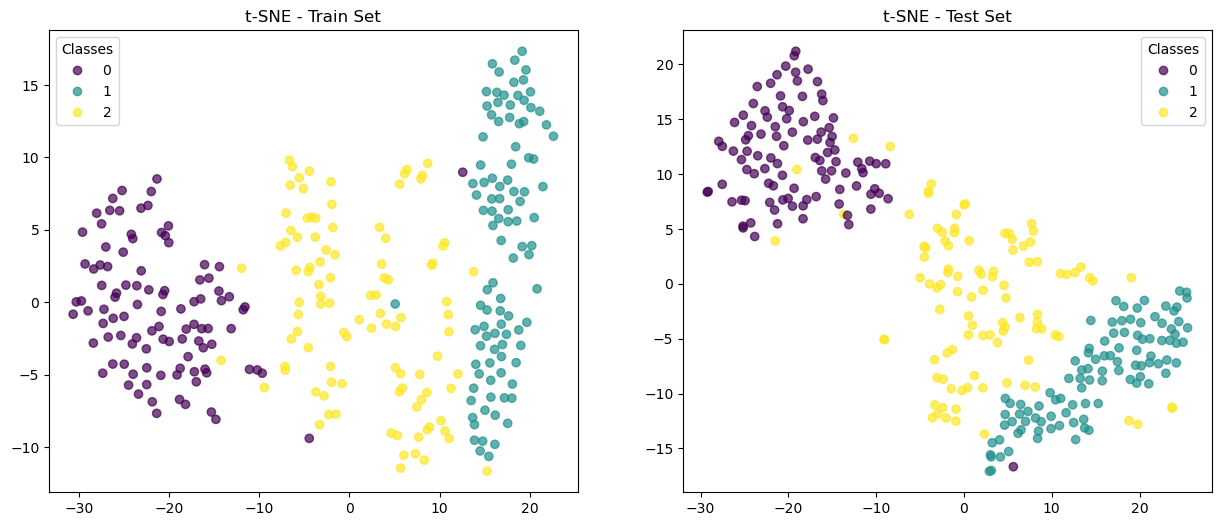

In [11]:
train_images, train_labels = load_dataset(train_images_fpath, train_labels_fpath)
test_images, test_labels = load_dataset(test_images_fpath, test_labels_fpath)

filtered_train_images, filtered_train_labels = filter012(train_images, train_labels)
filtered_test_images, filtered_test_labels = filter012(test_images, test_labels)

sampled_train_images, sampled_train_labels = sample_data(filtered_train_images, filtered_train_labels, sample_size=100)
sampled_test_images, sampled_test_labels = sample_data(filtered_test_images, filtered_test_labels, sample_size=100)

preprocessed_train_images = preprocess(sampled_train_images)
preprocessed_test_images = preprocess(sampled_test_images)

params = MLEstimate(preprocessed_train_images, sampled_train_labels)
lda_pred_labels, lda_accuracy = LDA(preprocessed_test_images, sampled_test_labels, params)
qda_pred_labels, qda_accuracy = QDA(preprocessed_test_images, sampled_test_labels, params)
print(f"QDA Accuracy: {qda_accuracy:.4f}")
print("LDA Predicted Labels:", lda_pred_labels)
print("QDA Predicted Labels:", qda_pred_labels)
visualise(preprocessed_train_images, sampled_train_labels, preprocessed_test_images, sampled_test_labels)
